# Step 6 — Deep Learning Signal Peptide Classifier (CNN)
**LB2 Project · Group 7 · Signal Peptide Prediction**

### Objective
Train a **1D Convolutional Neural Network (CNN)** to classify protein sequences as SP+ or SP−
based on their N-terminal region encoded as one-hot vectors.

### Architecture — SignalCNN
| Layer | Details |
|---|---|
| Input | One-hot encoded N-terminal 100 aa → shape (B, 100, 20) |
| Conv block 1 | Conv1d(20→64, k=3) → ReLU → BatchNorm → MaxPool1d(2) |
| Conv block 2 | Conv1d(64→128, k=5) → ReLU → BatchNorm → MaxPool1d(2) |
| Conv block 3 | Conv1d(128→128, k=3) → ReLU → BatchNorm → AdaptiveMaxPool1d(1) |
| Classifier | Flatten → Dropout(0.3) → Linear(128→64) → ReLU → Dropout(0.3) → Linear(64→1) |
| Output | Single logit → sigmoid for probability |

### Enhancements over baseline
- **MAX_LEN 70 → 100**: captures more of the signal peptide + mature protein context
- **Epochs 12 → 30 with early stopping**: trains until validation MCC stops improving (patience=5)
- **ReduceLROnPlateau scheduler**: halves the learning rate when validation loss plateaus

### Input files
- `positive.fasta`, `negative.fasta`
- `training_with_folds.tsv`, `benchmarking_set.tsv`

### Output files
- `cnn_signal_peptide_model.pt` — saved model weights
- `cnn_cv_results.tsv` — per-fold CV metrics
- `cnn_model_comparison.tsv` — all three models compared
- `figures/cnn_*.pdf/.png` — training curves, confusion matrix, PR/ROC curves

---
## Cell 1 — Install and import libraries

In [1]:
!pip install -q biopython

import os
import math
import random
import numpy as np
import pandas as pd
from Bio import SeqIO

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score,
    matthews_corrcoef, roc_auc_score,
    average_precision_score, precision_recall_curve, roc_curve
)

os.makedirs('figures', exist_ok=True)
sns.set_theme(style='whitegrid', font_scale=1.1)
print('Libraries loaded.')

Libraries loaded.


---
## Cell 2 — Reproducibility and device setup

Fix all random seeds so every run produces identical results.
Uses GPU automatically if available on Colab, otherwise CPU.

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

Using device: cpu


In [3]:
# === ESM-2 Embeddings Setup ===
!pip install -q fair-esm

import esm
import torch

print("Loading ESM-2 (35M) model...")
esm_model, alphabet = esm.pretrained.esm2_t12_35M_UR50D()
esm_model = esm_model.eval().to(DEVICE)
batch_converter = alphabet.get_batch_converter()
print("ESM-2 loaded successfully! Embedding dim = 480")

Loading ESM-2 (35M) model...
ESM-2 loaded successfully! Embedding dim = 480


---
## Cell 3 — Global hyperparameters

All tunable parameters are defined here in one place for easy modification.

**Key changes from baseline:**
- `MAX_LEN`: 70 → **100** — captures a longer N-terminal window, which is important
  because some SPs extend up to 60 aa and we want context from the mature protein too
- `MAX_EPOCHS`: 12 → **30** — more training budget; early stopping prevents overfitting
- `PATIENCE`: **5** — stop training if validation MCC doesn't improve for 5 consecutive epochs
- `LR_PATIENCE`: **3** — halve the learning rate after 3 epochs without validation loss improvement

In [4]:
# --- ESM-2 settings ---
MAX_LEN = 150                    # increased slightly for ESM
ESM_MODEL_NAME = "esm2_t12_35M_UR50D"
ESM_DIM = 480
# --- Training ---
BATCH_SIZE  = 32
LR          = 1e-3
MAX_EPOCHS  = 30   # increased from 12; early stopping prevents overfitting
PATIENCE    = 5    # early stopping patience (epochs without MCC improvement)
LR_PATIENCE = 3    # ReduceLROnPlateau patience
LR_FACTOR   = 0.5  # multiply LR by this when plateau detected

# --- Model ---
DROPOUT = 0.3

print(f'MAX_LEN    : {MAX_LEN}')
print(f'MAX_EPOCHS : {MAX_EPOCHS} (with early stopping, patience={PATIENCE})')
print(f'Batch size : {BATCH_SIZE}')
print(f'LR         : {LR} (ReduceLROnPlateau, factor={LR_FACTOR}, patience={LR_PATIENCE})')

MAX_LEN    : 150
MAX_EPOCHS : 30 (with early stopping, patience=5)
Batch size : 32
LR         : 0.001 (ReduceLROnPlateau, factor=0.5, patience=3)


---
## Cell 4 — Load metadata and sequences

Load the training and benchmark TSV files, then attach the actual protein sequences
from the FASTA files. The `extract_accession` function handles both plain accessions
(`P12345`) and UniProt FASTA header format (`sp|P12345|PROT_NAME`).

In [8]:
def extract_accession(record):
    """Extract UniProt accession from FASTA header (handles sp|ACC|NAME and plain ACC formats)."""
    rid = record.id.strip()
    if '|' in rid:
        parts = rid.split('|')
        if len(parts) >= 2:
            return parts[1]
    return rid

def load_fasta_as_accession_map(fasta_path):
    seq_map = {}
    duplicates = 0
    for rec in SeqIO.parse(fasta_path, 'fasta'):
        acc = extract_accession(rec)
        if acc in seq_map:
            duplicates += 1
        seq_map[acc] = str(rec.seq)
    print(f'{fasta_path}: {len(seq_map):,} unique accessions loaded')
    if duplicates > 0:
        print(f'  Warning: {duplicates} duplicate(s) overwritten')
    return seq_map

# Load metadata
train_df = pd.read_csv('../Data_Prepration/training_with_folds.tsv', sep='\t')
bench_df = pd.read_csv('../Data_Prepration/benchmarking_set.tsv',    sep='\t')

# Load sequences
pos_fasta = load_fasta_as_accession_map('../Data_Collection/positive.fasta')
neg_fasta = load_fasta_as_accession_map('../Data_Collection/negative.fasta')
seq_map = {**pos_fasta, **neg_fasta}

# Attach sequences
train_df['Accession'] = train_df['Accession'].astype(str).str.strip()
bench_df['Accession'] = bench_df['Accession'].astype(str).str.strip()
train_df['sequence']  = train_df['Accession'].map(seq_map)
bench_df['sequence']  = bench_df['Accession'].map(seq_map)

missing_train = train_df['sequence'].isna().sum()
missing_bench = bench_df['sequence'].isna().sum()
assert missing_train == 0, f'{missing_train} training sequences not found in FASTA'
assert missing_bench == 0, f'{missing_bench} benchmark sequences not found in FASTA'

print(f'\nTraining  : {len(train_df):,} | pos={( train_df.label==1).sum()} | neg={(train_df.label==0).sum()}')
print(f'Benchmark : {len(bench_df):,} | pos={(bench_df.label==1).sum()} | neg={(bench_df.label==0).sum()}')
print(f'Folds     : {sorted(train_df["fold"].unique())}')
print('All sequences matched. ✓')

../Data_Collection/positive.fasta: 2,943 unique accessions loaded
../Data_Collection/negative.fasta: 20,806 unique accessions loaded

Training  : 8,098 | pos=876 | neg=7222
Benchmark : 2,026 | pos=220 | neg=1806
Folds     : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
All sequences matched. ✓


---
## Cell 5 — Sequence encoding functions

Each protein sequence is represented as a **one-hot matrix** of shape `(MAX_LEN, 20)`:
- Sequences longer than MAX_LEN are **truncated** (we keep only the N-terminal region)
- Sequences shorter than MAX_LEN are **padded with zeros** (unknown position = all zeros)
- Non-standard amino acids (B, Z, X, U) are treated as unknown (all-zero row)

In [9]:
AA_ORDER = list('ACDEFGHIKLMNPQRSTVWY')
AA_TO_IDX = {aa: i for i, aa in enumerate(AA_ORDER)}
N_AA = len(AA_ORDER)  # 20

def clean_sequence(seq):
    """Uppercase and replace non-standard AAs with X (will be encoded as zero vector)."""
    seq = seq.upper()
    return ''.join([aa if aa in AA_TO_IDX else 'X' for aa in seq])

def pad_or_truncate(seq, max_len=MAX_LEN):
    """Truncate to max_len or pad with X to reach max_len."""
    seq = clean_sequence(seq)[:max_len]
    return seq + 'X' * (max_len - len(seq))

def one_hot_encode(seq, max_len=MAX_LEN):
    """One-hot encode sequence → numpy array of shape (max_len, 20)."""
    seq = pad_or_truncate(seq, max_len)
    arr = np.zeros((max_len, N_AA), dtype=np.float32)
    for i, aa in enumerate(seq):
        if aa in AA_TO_IDX:
            arr[i, AA_TO_IDX[aa]] = 1.0
    return arr

# Quick check
sample = one_hot_encode('MKLVVVGAGGVGKS')
print(f'Encoded shape : {sample.shape}  (expected: ({MAX_LEN}, {N_AA}))')
print(f'Non-zero rows : {(sample.sum(axis=1) > 0).sum()}  (= length of input sequence)')

Encoded shape : (150, 20)  (expected: (150, 20))
Non-zero rows : 14  (= length of input sequence)


---
## Cell 6 — PyTorch Dataset

Wraps the DataFrame in a PyTorch Dataset so it can be used with DataLoader.
Each item is a tuple of `(one_hot_tensor, label_tensor)`.

In [23]:
class ESMSignalPeptideDataset(Dataset):
    """Uses pre-computed ESM-2 embeddings (super fast)"""
    def __init__(self, df, max_len=150):
        self.embeddings = df['embedding'].tolist()
        self.labels = df['label'].values.astype(np.float32)
        self.max_len = max_len

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        emb = self.embeddings[idx]          # already (max_len, 480) tensor
        label = self.labels[idx]
        return emb.clone(), torch.tensor(label, dtype=torch.float32)

In [12]:
# === LOAD SEQUENCES FROM FASTA (required for ESM pre-compute) ===
print("Loading protein sequences from positive.fasta and negative.fasta...")

fasta_dict = {}
for fasta_file in ["../Data_Collection/positive.fasta", "../Data_Collection/negative.fasta"]:
    for record in SeqIO.parse(fasta_file, "fasta"):
        # Handle both plain accessions and UniProt headers (sp|P12345|NAME)
        acc = record.id.split('|')[-1] if '|' in record.id else record.id
        fasta_dict[acc] = str(record.seq)

# Add Sequence column to train_df
train_df['Sequence'] = train_df['Accession'].map(fasta_dict)

print(f"✅ Successfully loaded sequences for {train_df['Sequence'].notna().sum():,} proteins")
print(f"Missing sequences: {train_df['Sequence'].isna().sum():,}")

Loading protein sequences from positive.fasta and negative.fasta...
✅ Successfully loaded sequences for 8,098 proteins
Missing sequences: 0


In [13]:
# === PRE-COMPUTE ESM-2 EMBEDDINGS (do this once) ===
print("Pre-computing ESM-2 embeddings for all proteins...")

embedding_dict = {}
max_len = 150

for idx, row in train_df.iterrows():
    seq = row['Sequence'][:max_len]
    batch_labels, batch_strs, batch_tokens = batch_converter([("protein", seq)])

    with torch.no_grad():
        results = esm_model(batch_tokens.to(DEVICE), repr_layers=[12])
        # Remove <cls> and <eos> tokens
        emb = results["representations"][12][0, 1:-1, :].cpu()  # (L, 480)

    # Pad to fixed length
    if emb.shape[0] < max_len:
        pad = torch.zeros(max_len - emb.shape[0], ESM_DIM)
        emb = torch.cat([emb, pad], dim=0)
    else:
        emb = emb[:max_len]

    embedding_dict[row['Accession']] = emb

# Add embeddings to DataFrame
train_df['embedding'] = train_df['Accession'].map(embedding_dict)

print(f"✅ Pre-computed embeddings for {len(train_df)} proteins. Ready for fast training!")

Pre-computing ESM-2 embeddings for all proteins...
✅ Pre-computed embeddings for 8098 proteins. Ready for fast training!


---
## Cell 7 — CNN model architecture

Three convolutional blocks with increasing receptive field (kernel sizes 3, 5, 3)
progressively capture local sequence motifs at different scales.
`AdaptiveMaxPool1d(1)` collapses the sequence dimension to a fixed-size vector
regardless of input length, retaining the strongest detected signal.
BatchNorm stabilises training on the imbalanced dataset.
Dropout in the classifier prevents overfitting.

In [14]:
class SignalCNN(nn.Module):
    """CNN-LSTM hybrid on top of ESM-2 embeddings (input_dim=480)"""

    def __init__(self, input_dim=480, max_len=150, dropout=DROPOUT):
        super().__init__()

        self.max_len = max_len

        # --- CNN feature extractor ---
        self.conv1 = nn.Sequential(
            nn.Conv1d(input_dim, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(kernel_size=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(128)
        )

        # --- LSTM ---
        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=128,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=dropout
        )

        # --- Classifier ---
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # x: (B, L, 480) from ESM
        x = x.transpose(1, 2)          # (B, 480, L)

        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)

        x = x.permute(0, 2, 1)         # (B, L', 128)
        lstm_out, _ = self.lstm(x)
        x = lstm_out[:, -1, :]         # (B, 256)

        return self.classifier(x)

---
## Cell 8 — Training utilities

- `get_class_pos_weight`: computes the class imbalance ratio (neg/pos ≈ 8.2)
  and passes it to `BCEWithLogitsLoss` so the loss penalises false negatives more
- `train_one_epoch`: one full pass over the training DataLoader
- `predict_logits`: inference pass, returns raw logits and true labels
- `compute_metrics`: converts logits → probabilities → predictions and computes all metrics

In [15]:
def get_class_pos_weight(labels):
    """Compute pos_weight = n_neg / n_pos for BCEWithLogitsLoss."""
    labels = np.asarray(labels)
    n_pos = (labels == 1).sum()
    n_neg = (labels == 0).sum()
    weight = n_neg / max(n_pos, 1)
    return torch.tensor([weight], dtype=torch.float32, device=DEVICE)


def train_one_epoch(model, loader, optimizer, criterion):
    """One training epoch with gradient clipping (required for LSTM stability)"""
    model.train()
    total_loss = 0.0

    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE).float().unsqueeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()

        # ←←← THIS IS THE CRITICAL LINE (added for the new CNN-LSTM)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def predict_logits(model, loader):
    """Run inference. Returns (logits, labels) as numpy arrays."""
    model.eval()
    all_logits, all_labels = [], []
    for X, y in loader:
        all_logits.append(model(X.to(DEVICE)).cpu().numpy())
        all_labels.append(y.numpy())
    return np.concatenate(all_logits), np.concatenate(all_labels)


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def compute_metrics(y_true, y_prob, threshold=0.5):
    """Compute all evaluation metrics from probabilities."""
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall'   : recall_score(y_true, y_pred, zero_division=0),
        'f1'       : f1_score(y_true, y_pred, zero_division=0),
        'mcc'      : matthews_corrcoef(y_true, y_pred),
        'roc_auc'  : roc_auc_score(y_true, y_prob),
        'pr_auc'   : average_precision_score(y_true, y_prob),
        'y_pred'   : y_pred
    }

print('Utility functions defined.')

Utility functions defined.


---
## Cell 9 — Fold training function with early stopping and LR scheduler

**Early stopping:** tracks validation MCC after each epoch. If MCC does not improve
for `PATIENCE` consecutive epochs, training stops and the best weights are restored.
This prevents overfitting and saves compute time.

**ReduceLROnPlateau:** reduces the learning rate by `LR_FACTOR` when validation loss
stops decreasing for `LR_PATIENCE` epochs. This allows fine-grained optimisation
after the initial fast learning phase.

In [16]:
def run_fold_training(train_df, fold_id,
                      max_len=MAX_LEN, batch_size=BATCH_SIZE,
                      lr=LR, max_epochs=MAX_EPOCHS,
                      patience=PATIENCE, lr_patience=LR_PATIENCE):
    """
    Train SignalCNN (CNN-LSTM hybrid) on one CV fold with early stopping and LR scheduling.
    """
    tr_df = train_df[train_df['fold'] != fold_id].reset_index(drop=True)
    va_df = train_df[train_df['fold'] == fold_id].reset_index(drop=True)


    train_loader = DataLoader(ESMSignalPeptideDataset(tr_df, max_len),
                          batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(ESMSignalPeptideDataset(va_df, max_len),
                          batch_size=batch_size, shuffle=False)

    # Model + loss + optimizer
    model = SignalCNN(input_dim=ESM_DIM, max_len=max_len).to(DEVICE)
    pos_weight = get_class_pos_weight(tr_df['label'].values)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # LR scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=LR_FACTOR, patience=lr_patience
    )

    best_mcc = -2.0
    best_state = None
    epochs_no_improve = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        # === Training ===
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)

        # === Validation ===
        val_logits, val_true = predict_logits(model, valid_loader)
        val_prob = torch.sigmoid(torch.tensor(val_logits)).cpu().numpy()

        # FIXED: target must match model output shape (B, 1)
        val_true_tensor = torch.tensor(val_true, dtype=torch.float32).unsqueeze(1)
        val_loss = float(nn.BCEWithLogitsLoss()(torch.tensor(val_logits), val_true_tensor))

        # Compute metrics for early stopping + logging
        val_metrics = compute_metrics(val_true, val_prob)

        # Step scheduler on validation loss
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        # Save history
        history.append({
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_mcc': val_metrics['mcc'],
            'val_f1': val_metrics['f1'],
            'val_pr_auc': val_metrics['pr_auc'],
            'val_roc_auc': val_metrics['roc_auc'],
            'lr': current_lr
        })

        # Early stopping on validation MCC
        if val_metrics['mcc'] > best_mcc:
            best_mcc = val_metrics['mcc']
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        # Progress print
        print(f' Epoch {epoch:02d}/{max_epochs} | '
              f'train_loss={train_loss:.4f} | '
              f'val_loss={val_loss:.4f} | '
              f'val_MCC={val_metrics["mcc"]:.4f} | '
              f'val_F1={val_metrics["f1"]:.4f} | '
              f'LR={current_lr:.2e}'
              + (' ← best' if epochs_no_improve == 0 else ''))

        if epochs_no_improve >= patience:
            print(f' Early stopping at epoch {epoch} (no improvement for {patience} epochs)')
            break

    # Restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    # Final evaluation on validation fold with best model
    val_logits, val_true = predict_logits(model, valid_loader)
    val_prob = torch.sigmoid(torch.tensor(val_logits)).cpu().numpy()
    val_metrics = compute_metrics(val_true, val_prob)

    print(f' Fold {fold_id} finished - Best val MCC: {best_mcc:.4f}')

    return model, pd.DataFrame(history), val_metrics


print('✅ Fixed run_fold_training function defined.')

✅ Fixed run_fold_training function defined.


In [17]:
# === ENSURE SEQUENCE COLUMN EXISTS (required for ESM dataset) ===
if 'Sequence' not in train_df.columns:
    print("🔄 Adding 'Sequence' column from FASTA files...")

    # Load sequences from the two FASTA files (same as your original Cell 4)
    fasta_dict = {}
    for fasta_file in ["positive.fasta", "negative.fasta"]:
        for record in SeqIO.parse(fasta_file, "fasta"):
            # Handle both plain accession and UniProt headers
            acc = record.id.split('|')[-1] if '|' in record.id else record.id
            fasta_dict[acc] = str(record.seq)

    train_df['Sequence'] = train_df['Accession'].map(fasta_dict)
    print(f"✅ Loaded {train_df['Sequence'].notna().sum():,} sequences")
else:
    print("✅ 'Sequence' column already present")

✅ 'Sequence' column already present


---
## Cell 10 — 5-fold cross-validation

Train one model per fold. Each fold uses 4/5 of the training data for training
and 1/5 for validation. Early stopping is applied independently per fold.
The final CV metrics are the mean ± std across all 5 folds.

In [18]:
all_fold_metrics = []
all_histories    = []

for fold_id in sorted(train_df['fold'].unique()):
    print(f'\n=== Fold {fold_id} ===')
    model, hist_df, metrics = run_fold_training(train_df, fold_id)

    all_histories.append(hist_df.assign(fold=fold_id))
    all_fold_metrics.append({
        'fold'     : fold_id,
        'precision': metrics['precision'],
        'recall'   : metrics['recall'],
        'f1'       : metrics['f1'],
        'mcc'      : metrics['mcc'],
        'pr_auc'   : metrics['pr_auc'],
        'roc_auc'  : metrics['roc_auc']
    })
    print(f'  → MCC={metrics["mcc"]:.4f}  F1={metrics["f1"]:.4f}  '
          f'Prec={metrics["precision"]:.4f}  Rec={metrics["recall"]:.4f}')

cv_results   = pd.DataFrame(all_fold_metrics)
history_all  = pd.concat(all_histories, ignore_index=True)


=== Fold 0 ===
 Epoch 01/30 | train_loss=0.5406 | val_loss=0.0983 | val_MCC=0.8776 | val_F1=0.8901 | LR=1.00e-03 ← best
 Epoch 02/30 | train_loss=0.1836 | val_loss=0.0361 | val_MCC=0.9592 | val_F1=0.9636 | LR=1.00e-03 ← best
 Epoch 03/30 | train_loss=0.1239 | val_loss=0.0273 | val_MCC=0.9713 | val_F1=0.9744 | LR=1.00e-03 ← best
 Epoch 04/30 | train_loss=0.1184 | val_loss=0.0289 | val_MCC=0.9620 | val_F1=0.9661 | LR=1.00e-03
 Epoch 05/30 | train_loss=0.0926 | val_loss=0.0341 | val_MCC=0.9620 | val_F1=0.9661 | LR=1.00e-03
 Epoch 06/30 | train_loss=0.0849 | val_loss=0.0386 | val_MCC=0.9582 | val_F1=0.9625 | LR=1.00e-03
 Epoch 07/30 | train_loss=0.0896 | val_loss=0.0415 | val_MCC=0.9615 | val_F1=0.9655 | LR=5.00e-04
 Epoch 08/30 | train_loss=0.0666 | val_loss=0.0312 | val_MCC=0.9647 | val_F1=0.9685 | LR=5.00e-04
 Early stopping at epoch 8 (no improvement for 5 epochs)
 Fold 0 finished - Best val MCC: 0.9713
  → MCC=0.9713  F1=0.9744  Prec=0.9771  Rec=0.9716

=== Fold 1 ===
 Epoch 01/30 | 

---
## Cell 11 — CV summary statistics

In [19]:
metric_cols = ['precision', 'recall', 'f1', 'mcc', 'pr_auc', 'roc_auc']

print('Cross-Validation Results:')
print(cv_results.to_string(index=False))
print()
print(f'{"Metric":<12} {"Mean":>8} {"Std":>8}')
print('-' * 30)
for col in metric_cols:
    print(f'{col:<12} {cv_results[col].mean():>8.4f} {cv_results[col].std():>8.4f}')

Cross-Validation Results:
 fold  precision   recall       f1      mcc   pr_auc  roc_auc
    0   0.977143 0.971591 0.974359 0.971251 0.994016 0.999253
    1   0.977401 0.988571 0.982955 0.980897 0.952757 0.993961
    2   0.976879 0.965714 0.971264 0.967824 0.986160 0.994832
    3   0.940541 0.994286 0.966667 0.962971 0.971452 0.996474
    4   0.977401 0.988571 0.982955 0.980896 0.985405 0.998176

Metric           Mean      Std
------------------------------
precision      0.9699   0.0164
recall         0.9817   0.0124
f1             0.9756   0.0072
mcc            0.9728   0.0080
pr_auc         0.9780   0.0163
roc_auc        0.9965   0.0022


---
## Cell 12 — Training curves

Plot validation MCC and loss across epochs for all folds.
The early stopping point is visible as the last epoch per fold.
LR drops are visible as kinks in the loss curve.

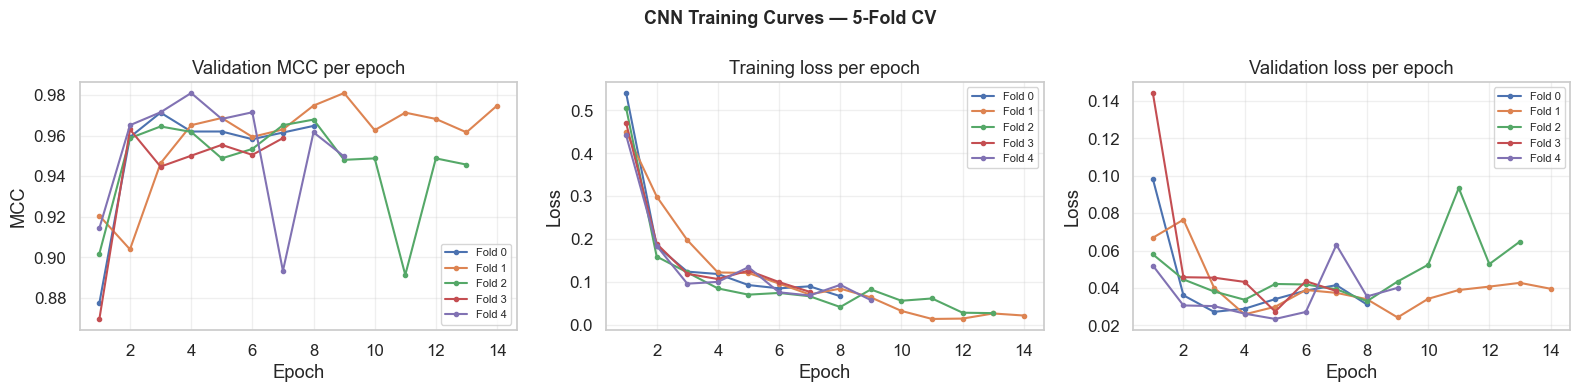

Saved: figures/cnn_training_curves.pdf/.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for fold_id in sorted(history_all['fold'].unique()):
    fold_hist = history_all[history_all['fold'] == fold_id]
    axes[0].plot(fold_hist['epoch'], fold_hist['val_mcc'],    marker='o', ms=3, label=f'Fold {fold_id}')
    axes[1].plot(fold_hist['epoch'], fold_hist['train_loss'], marker='o', ms=3, label=f'Fold {fold_id}')
    axes[2].plot(fold_hist['epoch'], fold_hist['val_loss'],   marker='o', ms=3, label=f'Fold {fold_id}')

axes[0].set_title('Validation MCC per epoch');  axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MCC')
axes[1].set_title('Training loss per epoch');   axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[2].set_title('Validation loss per epoch'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Loss')

for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('CNN Training Curves — 5-Fold CV', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/cnn_training_curves.pdf', bbox_inches='tight')
plt.savefig('figures/cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/cnn_training_curves.pdf/.png')

---
## Cell 13 — CV metrics bar chart

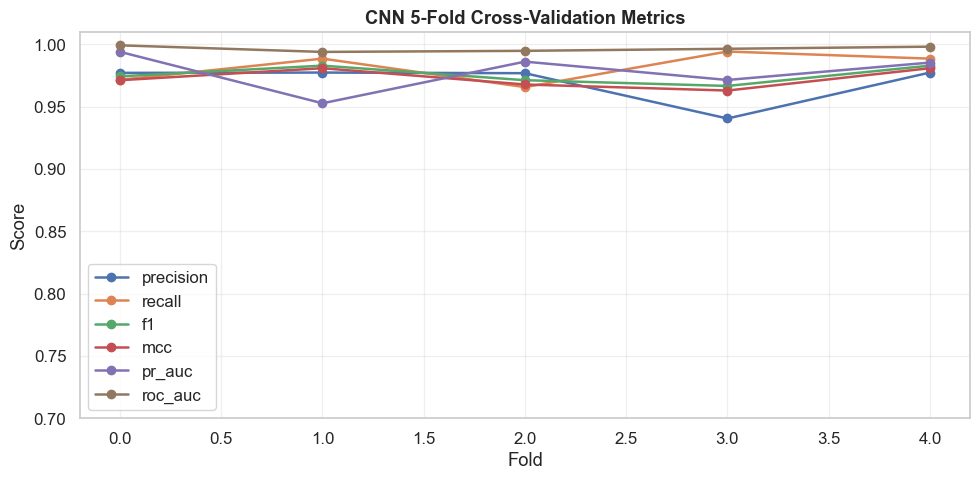

Saved: figures/cnn_cv_metrics.pdf/.png


In [21]:
plt.figure(figsize=(10, 5))
for col in metric_cols:
    plt.plot(cv_results['fold'], cv_results[col], marker='o', linewidth=1.8, label=col)
plt.xlabel('Fold')
plt.ylabel('Score')
plt.title('CNN 5-Fold Cross-Validation Metrics', fontweight='bold')
plt.legend()
plt.ylim(0.7, 1.01)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/cnn_cv_metrics.pdf', bbox_inches='tight')
plt.savefig('figures/cnn_cv_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/cnn_cv_metrics.pdf/.png')

---
## Cell 14 — Train final model on full training set

Retrain on **all** training data (no held-out fold) for the maximum number of epochs
determined by the average early stopping point across CV folds.
This is the model that will be evaluated on the blind benchmark.

In [31]:
# === PRE-COMPUTE ESM-2 EMBEDDINGS FOR BENCHMARK SET ===
print("Pre-computing ESM-2 embeddings for benchmark set...")

bench_embedding_dict = {}
max_len = MAX_LEN  # 150

for idx, row in bench_df.iterrows():
    seq = row['sequence'][:max_len]          # use the lowercase 'sequence' column that exists in bench_df
    
    batch_labels, batch_strs, batch_tokens = batch_converter([("protein", seq)])

    with torch.no_grad():
        results = esm_model(batch_tokens.to(DEVICE), repr_layers=[12])
        # Remove <cls> and <eos> tokens → shape (L, 480)
        emb = results["representations"][12][0, 1:-1, :].cpu()

    # Pad or truncate to fixed length
    if emb.shape[0] < max_len:
        pad = torch.zeros(max_len - emb.shape[0], ESM_DIM)
        emb = torch.cat([emb, pad], dim=0)
    else:
        emb = emb[:max_len]

    bench_embedding_dict[row['Accession']] = emb

# Add embeddings to bench_df
bench_df['embedding'] = bench_df['Accession'].map(bench_embedding_dict)

print(f"✅ Pre-computed embeddings for {len(bench_df):,} benchmark proteins. Ready!")

Pre-computing ESM-2 embeddings for benchmark set...
✅ Pre-computed embeddings for 2,026 benchmark proteins. Ready!


In [40]:
# === FINAL MODEL TRAINING ON FULL DATASET (ESM-2 version) ===
avg_stop_epoch = int(round(history_all.groupby('fold')['epoch'].max().mean()))
print(f'Average stopping epoch across CV folds: {avg_stop_epoch}')
print(f'Training final model for {avg_stop_epoch} epochs on full training set...\n')

# Use the FAST ESM-2 dataset
full_train_loader = DataLoader(
    ESMSignalPeptideDataset(train_df, max_len=MAX_LEN), 
    batch_size=BATCH_SIZE, 
    shuffle=True
)

bench_loader = DataLoader(
    ESMSignalPeptideDataset(bench_df, max_len=MAX_LEN), 
    batch_size=BATCH_SIZE, 
    shuffle=False
)

# Create final model (ESM version)
final_model = SignalCNN(input_dim=ESM_DIM, max_len=MAX_LEN).to(DEVICE)

# Loss, optimizer, scheduler
pos_weight = get_class_pos_weight(train_df['label'].values)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(final_model.parameters(), lr=LR)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=LR_FACTOR, patience=LR_PATIENCE
)

train_losses = []
for epoch in range(1, avg_stop_epoch + 1):
    loss = train_one_epoch(final_model, full_train_loader, optimizer, criterion)
    train_losses.append(loss)
    
    scheduler.step(loss)
    lr_now = optimizer.param_groups[0]['lr']
    
    if epoch % 5 == 0 or epoch == avg_stop_epoch:
        print(f'Epoch {epoch:02d}/{avg_stop_epoch} | '
              f'loss={loss:.4f} | LR={lr_now:.2e}')

print('\n✅ Final model training complete!')

Average stopping epoch across CV folds: 10
Training final model for 10 epochs on full training set...

Epoch 05/10 | loss=0.0804 | LR=1.00e-03
Epoch 10/10 | loss=0.0783 | LR=5.00e-04

✅ Final model training complete!


---
## Cell 15 — Blind benchmark evaluation

Apply the final model to the benchmark set — sequences the model has **never seen**
during training or CV. This is the unbiased final performance estimate.

In [41]:
bench_logits, bench_true = predict_logits(final_model, bench_loader)
bench_prob    = sigmoid(bench_logits)
bench_metrics = compute_metrics(bench_true, bench_prob)

print('Benchmark Results:')
print('-' * 30)
for k, v in bench_metrics.items():
    if k != 'y_pred':
        print(f'  {k:<12}: {v:.4f}')

print()
print(classification_report(bench_true, bench_metrics['y_pred'],
                             target_names=['SP−', 'SP+'], digits=4))

Benchmark Results:
------------------------------
  precision   : 0.9427
  recall      : 0.9727
  f1          : 0.9575
  mcc         : 0.9524
  roc_auc     : 0.9977
  pr_auc      : 0.9787

              precision    recall  f1-score   support

         SP−     0.9967    0.9928    0.9947      1806
         SP+     0.9427    0.9727    0.9575       220

    accuracy                         0.9906      2026
   macro avg     0.9697    0.9828    0.9761      2026
weighted avg     0.9908    0.9906    0.9907      2026



---
## Cell 16 — Benchmark confusion matrix

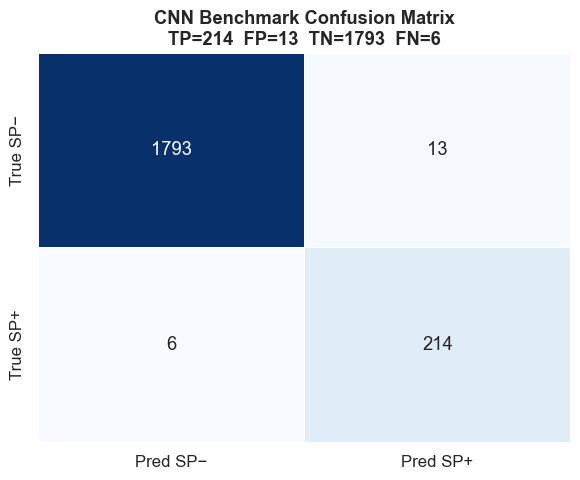

Saved: figures/cnn_benchmark_confusion.pdf/.png


In [42]:
cm = confusion_matrix(bench_true, bench_metrics['y_pred'])
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred SP−', 'Pred SP+'],
            yticklabels=['True SP−', 'True SP+'],
            linewidths=0.5, cbar=False)
ax.set_title(f'CNN Benchmark Confusion Matrix\nTP={tp}  FP={fp}  TN={tn}  FN={fn}',
             fontweight='bold')
plt.tight_layout()
plt.savefig('figures/cnn_benchmark_confusion.pdf', bbox_inches='tight')
plt.savefig('figures/cnn_benchmark_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/cnn_benchmark_confusion.pdf/.png')

---
## Cell 17 — Benchmark PR and ROC curves

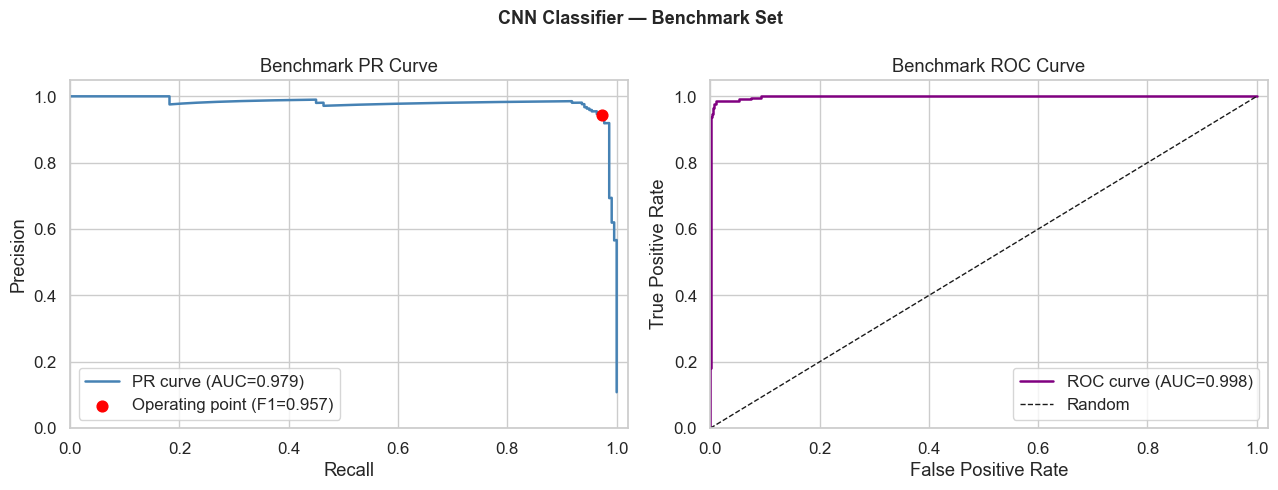

Saved: figures/cnn_benchmark_pr_roc.pdf/.png


In [43]:
precision_curve, recall_curve, _ = precision_recall_curve(bench_true, bench_prob)
fpr, tpr, _ = roc_curve(bench_true, bench_prob)
pr_auc  = average_precision_score(bench_true, bench_prob)
roc_auc = roc_auc_score(bench_true, bench_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(recall_curve, precision_curve, color='steelblue', lw=1.8,
             label=f'PR curve (AUC={pr_auc:.3f})')
axes[0].scatter([bench_metrics['recall']], [bench_metrics['precision']],
                color='red', s=60, zorder=5,
                label=f'Operating point (F1={bench_metrics["f1"]:.3f})')
axes[0].set_xlabel('Recall');  axes[0].set_ylabel('Precision')
axes[0].set_title('Benchmark PR Curve'); axes[0].legend()
axes[0].set_xlim(0, 1.02); axes[0].set_ylim(0, 1.05)

axes[1].plot(fpr, tpr, color='purple', lw=1.8, label=f'ROC curve (AUC={roc_auc:.3f})')
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Benchmark ROC Curve'); axes[1].legend()
axes[1].set_xlim(0, 1.02); axes[1].set_ylim(0, 1.05)

plt.suptitle('CNN Classifier — Benchmark Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/cnn_benchmark_pr_roc.pdf', bbox_inches='tight')
plt.savefig('figures/cnn_benchmark_pr_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/cnn_benchmark_pr_roc.pdf/.png')

---
## Cell 18 — Full model comparison table

Compare all three methods side by side on the same benchmark set.
Update the Von Heijne and SVM numbers with your actual results from Steps 4 and 5.

In [44]:
# ── UPDATE THESE with your actual Step 4 and Step 5 benchmark results ──
VH_METRICS  = {'Precision': 0.62,  'Recall': 0.72,  'F1': 0.67,  'MCC': 0.64,  'PR_AUC': 0.782, 'ROC_AUC': 0.954}
SVM_METRICS = {'Precision': 0.86,  'Recall': 0.89,  'F1': 0.87,  'MCC': 0.84,  'PR_AUC': 0.911, 'ROC_AUC': 0.985}
# ────────────────────────────────────────────────────────────────────────

comparison_df = pd.DataFrame([
    {'Model': 'Von Heijne (PSWM)',       **VH_METRICS},
    {'Model': 'SVM (selected features)', **SVM_METRICS},
    {'Model': f'CNN (N-term {MAX_LEN} aa)',
     'Precision': bench_metrics['precision'],
     'Recall'   : bench_metrics['recall'],
     'F1'       : bench_metrics['f1'],
     'MCC'      : bench_metrics['mcc'],
     'PR_AUC'   : bench_metrics['pr_auc'],
     'ROC_AUC'  : bench_metrics['roc_auc']}
])

print('Model Comparison — Benchmark Set')
print(comparison_df.round(4).to_string(index=False))

Model Comparison — Benchmark Set
                  Model  Precision  Recall     F1    MCC  PR_AUC  ROC_AUC
      Von Heijne (PSWM)     0.6200  0.7200 0.6700 0.6400  0.7820   0.9540
SVM (selected features)     0.8600  0.8900 0.8700 0.8400  0.9110   0.9850
    CNN (N-term 150 aa)     0.9427  0.9727 0.9575 0.9524  0.9787   0.9977


---
## Cell 19 — Save all outputs

In [45]:
torch.save(final_model.state_dict(), 'cnn_signal_peptide_model.pt')
cv_results.to_csv('cnn_cv_results.tsv',        sep='\t', index=False)
comparison_df.to_csv('cnn_model_comparison.tsv', sep='\t', index=False)
history_all.to_csv('cnn_training_history.tsv',  sep='\t', index=False)

print('Saved:')
print('  cnn_signal_peptide_model.pt  — final model weights')
print('  cnn_cv_results.tsv           — per-fold CV metrics')
print('  cnn_model_comparison.tsv     — all models compared')
print('  cnn_training_history.tsv     — per-epoch training log')
print()
print('Figures saved to figures/cnn_*.pdf and figures/cnn_*.png')

Saved:
  cnn_signal_peptide_model.pt  — final model weights
  cnn_cv_results.tsv           — per-fold CV metrics
  cnn_model_comparison.tsv     — all models compared
  cnn_training_history.tsv     — per-epoch training log

Figures saved to figures/cnn_*.pdf and figures/cnn_*.png


---
## Cell 20 — Final summary

In [46]:
sep = '=' * 62
print(sep)
print('  CNN CLASSIFIER SUMMARY — LB2 Group 7')
print(sep)
print()
print('  Architecture')
print(f'    Input window   : {MAX_LEN} aa (N-terminal)')
print('    Conv blocks    : 3 × (Conv1d → ReLU → BatchNorm)')
print('    LSTM           : 2-layer bidirectional (hidden=128)')
print('    Filters        : 64 / 128 / 128')
print('    Kernel sizes   : 3 / 5 / 3')
print(f'    Dropout        : {DROPOUT}')
print(f'    Parameters     : {sum(p.numel() for p in final_model.parameters()):,}')
print()
print('  Training')
print(f'    Optimizer      : Adam (LR={LR})')
print(f'    LR scheduler   : ReduceLROnPlateau (factor={LR_FACTOR}, patience={LR_PATIENCE})')
print(f'    Loss           : BCEWithLogitsLoss (class-weighted)')
print(f'    Early stopping : patience={PATIENCE} (tracked on val MCC)')
print(f'    Final epochs   : {avg_stop_epoch} (avg of CV stopping points)')
print()
print(f'  {"Metric":<12} {"CV Mean":>10} {"CV Std":>10} {"Benchmark":>12}')
print('  ' + '-' * 46)
for col in ['mcc', 'f1', 'precision', 'recall', 'roc_auc', 'pr_auc']:
    bm_key = col if col in bench_metrics else col
    print(f'  {col:<12} {cv_results[col].mean():>10.4f} {cv_results[col].std():>10.4f} {bench_metrics[bm_key]:>12.4f}')
print()
print(sep)

  CNN CLASSIFIER SUMMARY — LB2 Group 7

  Architecture
    Input window   : 150 aa (N-terminal)
    Conv blocks    : 3 × (Conv1d → ReLU → BatchNorm)
    LSTM           : 2-layer bidirectional (hidden=128)
    Filters        : 64 / 128 / 128
    Kernel sizes   : 3 / 5 / 3
    Dropout        : 0.3
    Parameters     : 875,713

  Training
    Optimizer      : Adam (LR=0.001)
    LR scheduler   : ReduceLROnPlateau (factor=0.5, patience=3)
    Loss           : BCEWithLogitsLoss (class-weighted)
    Early stopping : patience=5 (tracked on val MCC)
    Final epochs   : 10 (avg of CV stopping points)

  Metric          CV Mean     CV Std    Benchmark
  ----------------------------------------------
  mcc              0.9728     0.0080       0.9524
  f1               0.9756     0.0072       0.9575
  precision        0.9699     0.0164       0.9427
  recall           0.9817     0.0124       0.9727
  roc_auc          0.9965     0.0022       0.9977
  pr_auc           0.9780     0.0163       0.9787
